# Project 1 · Diabetes 당뇨병 진행 예측

In [21]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ── 한글 폰트 설정 ────────────────────────────────────────
# 표나 그래프 라벨에서 표기되지 않는 공백 현상 방지
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans CJK JP']
    available  = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            matplotlib.rcParams['font.family'] = font
            print(f'한글 폰트 설정: {font}')
            return
    print('경고: 한글 폰트를 찾지 못했습니다. 시스템에 Nanum Gothic 등을 설치하세요.')

set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지

한글 폰트 설정: Malgun Gothic


In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# ── 1. 데이터 로드 ────────────────────────────────────────
diabetes = load_diabetes()
X1 = diabetes.data
y1 = diabetes.target

print(f'입력 데이터 형태 : {X1.shape}')
print(f'타겟 데이터 형태 : {y1.shape}')
print(f'타겟 범위        : {y1.min():.1f} ~ {y1.max():.1f}')
print(f'피처 이름        : {diabetes.feature_names}')

입력 데이터 형태 : (442, 10)
타겟 데이터 형태 : (442,)
타겟 범위        : 25.0 ~ 346.0
피처 이름        : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [3]:
# ── 2. 데이터 분리 (80% / 20%) ───────────────────────────
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)
print(f'학습용 : {X_train1.shape}')
print(f'테스트 : {X_test1.shape}')

학습용 : (353, 10)
테스트 : (89, 10)


In [22]:
# ── 3. 모델 · 손실함수 · gradient 정의 ───────────────────

def model1(X1, W1, b1):
    """선형 회귀: y_hat = XW + b1"""
    return X1.dot(W1) + b1


def mse1(y_pred, y_true):
    """Mean Squared Error"""
    return ((y_pred - y_true) ** 2).mean()


def gradient(X1, W1, b1, y1):
    """
    MSE 기울기 계산
    dL/dW1 = (2/N) * X1^T · (y_hat - y1)
    dL/db1 = (2/N) * sum(y_hat - y1)
    """
    N     = len(y1)
    error = model1(X1, W1, b1) - y1
    # BUG FIX: 두 구현 간 계수 2/N 으로 통일
    dW1 = (2 / N) * X1.T.dot(error)
    db1 = (2 / N) * error.sum()
    return dW1, db1

In [26]:
# ── 4. 경사하강법 학습 ────────────────────────────────────
import time

LEARNING_RATE = 0.1
EPOCHS        = 3000

np.random.seed(42)
W1 = np.random.rand(X_train1.shape[1])
b1 = np.random.rand()

loss_history = []
start = time.time()

for epoch in range(1, EPOCHS + 1):
    dW1, db1 = gradient(X_train1, W1, b1, y_train1)
    W1 -= LEARNING_RATE * dW1
    b1 -= LEARNING_RATE * db1
    L1 = mse1(model1(X_train1, W1, b1), y_train1)
    loss_history.append(L1)
    if epoch % 500 == 0 or epoch == 1:
        print(f'Epoch {epoch:5d} | Train MSE: {L1:.2f}')

print(f'\n학습 완료 | 소요 시간: {time.time() - start:.3f}초')

Epoch     1 | Train MSE: 21174.87
Epoch   500 | Train MSE: 4005.76
Epoch  1000 | Train MSE: 3442.98
Epoch  1500 | Train MSE: 3214.58
Epoch  2000 | Train MSE: 3094.02
Epoch  2500 | Train MSE: 3022.86
Epoch  3000 | Train MSE: 2979.01

학습 완료 | 소요 시간: 0.197초


In [27]:
# ── 5. 테스트 성능 평가 ───────────────────────────────────
y_pred_train = model1(X_train1, W1, b1)
y_pred_test  = model1(X_test1,  W1, b1)

train_mse = mse1(y_pred_train, y_train1)
test_mse  = mse1(y_pred_test,  y_test1)

# BUG FIX: f-string 오기 수정 (원본: f"...MSE): .{test_loss:.4f}")
print(f'Train MSE : {train_mse:.2f}')
print(f'Test  MSE : {test_mse:.2f}')
print(f'Test  RMSE: {np.sqrt(test_mse):.2f}')

Train MSE : 2979.01
Test  MSE : 2870.47
Test  RMSE: 53.58


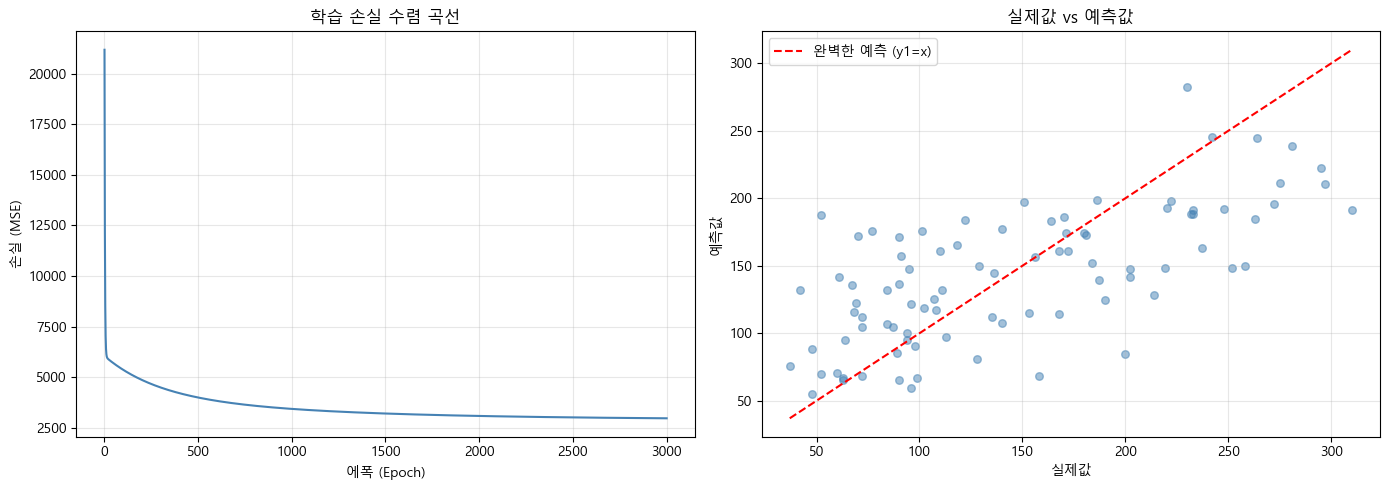

In [28]:
# ── 6. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) 손실 수렴 곡선
axes[0].plot(range(1, EPOCHS + 1), loss_history, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('에폭 (Epoch)')
axes[0].set_ylabel('손실 (MSE)')
axes[0].set_title('학습 손실 수렴 곡선')
axes[0].grid(alpha=0.3)

# (B) 실제값 vs 예측값
# BUG FIX: 원본 Cell 15는 X_test1[:,0] 을 x축으로 잘못 사용
#          → 표준: 실제값(y_test1) vs 예측값(y_pred) scatter
lo = min(y_test1.min(), y_pred_test.min())
hi = max(y_test1.max(), y_pred_test.max())
axes[1].scatter(y_test1, y_pred_test, alpha=0.5, color='steelblue', s=30)
axes[1].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='완벽한 예측 (y1=x)')
axes[1].set_xlabel('실제값')
axes[1].set_ylabel('예측값')
axes[1].set_title('실제값 vs 예측값')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ── 7. sklearn 정답 모델과 성능 비교 ─────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

sk_model = LinearRegression()
sk_model.fit(X_train1, y_train1)
sk_pred    = sk_model.predict(X_test1)
sk_mse     = mean_squared_error(y_test1, sk_pred)

print('=' * 42)
print(f'{"":20s} {"직접 구현":>9s}  {"sklearn":>8s}')
print('-' * 42)
print(f'{"Test MSE":20s} {test_mse:>9.2f}  {sk_mse:>8.2f}')
print(f'{"Test RMSE":20s} {np.sqrt(test_mse):>9.2f}  {np.sqrt(sk_mse):>8.2f}')
print('=' * 42)
print('두 값이 비슷할수록 경사하강법 구현이 정확합니다.')

                         직접 구현   sklearn
------------------------------------------
Test MSE               2885.97   2900.19
Test RMSE                53.72     53.85
두 값이 비슷할수록 경사하강법 구현이 정확합니다.


>**내용**  
>데이터 로드 : train.csv 와 test.csv  
>로그 변환 : count 데이터 왜도가 크기에 로그 변환 적용  
>특성 선택 : 모델 학습에 불필요한 열 제거, X(피처) y(타겟) 데이터 정의하였음  
>직접 구현 : model1 이라는 이름으로 가중치와 편향을 초기화, 경사하강법을 사용하여 MSE를 최소화하도록 학습  
>학습 루프 : EPOCHS(3000) 만큼 반복하며 오차의 기울기(Gradient)를 계산하고 가중치 업데이트  
>직접 구현 모델(model1) vs Scikit-learn : 두 모델의 MSE 와 RMSE를 출력하여 경사하강법이 얼마나 정밀하게 작동하는지 비교하였음. 두 모델의 성능이 거의 일치함을 확인  

>**결론**  
>학습 손실 곡선 : 에폭이 진행됩에 따라 손실(MSE)이 얼마나 잘 줄어드는지 그래프로 확인하여 학습의 안전성 검증하였음  
>실제값 vs 예측값 : 산점도를 그려 모델이 실제 대여 수요와 얼마나 가깝게 예측하고 있는지 파악  
>시간대별 패턴 분석 : 모델이 출퇴근 시간대의 수요 급증 패턴을 잘 포착하고 있는지, hour별 평균 대여 수를 통해 검증하였음  

# Project 2 · Bike Sharing 자전거 대여 수요 예측

In [31]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ────────────────────────────────────────
# 표나 그래프 라벨에서 표기되지 않는 공백 현상 방지
def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans CJK JP']
    available  = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            matplotlib.rcParams['font.family'] = font
            print(f'한글 폰트 설정: {font}')
            return
    print('경고: 한글 폰트를 찾지 못했습니다.')

set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False

한글 폰트 설정: Malgun Gothic


In [32]:
# ── 1. 데이터 로드 ────────────────────────────────────────
train = pd.read_csv('train.csv')
print(f'원본 shape: {train.shape}')
train.head(3)

원본 shape: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [33]:
# ── 2. datetime 파싱 & 피처 생성 ─────────────────────────
train['datetime'] = pd.to_datetime(train['datetime'])
train['year']  = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['hour']  = train['datetime'].dt.hour
print('minute 고유값:', train['datetime'].dt.minute.unique(), '← 전부 0, 불필요')
print('second 고유값:', train['datetime'].dt.second.unique(), '← 전부 0, 불필요')

minute 고유값: [0] ← 전부 0, 불필요
second 고유값: [0] ← 전부 0, 불필요


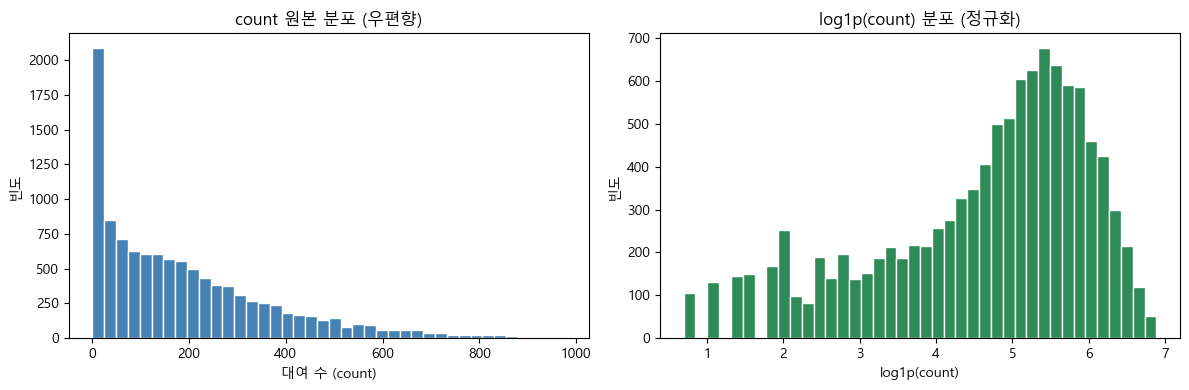

In [34]:
# ── 3. 타겟 분포 확인 & 로그 변환 ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['count'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('count 원본 분포 (우편향)')
axes[0].set_xlabel('대여 수 (count)')
axes[0].set_ylabel('빈도')

axes[1].hist(np.log1p(train['count']), bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('log1p(count) 분포 (정규화)')
axes[1].set_xlabel('log1p(count)')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

In [35]:
# ── 4. 피처 선택 ──────────────────────────────────────────
FEATURES = [
    'year', 'month', 'hour',        # 시간 피처
    'season', 'weather',            # 계절 · 날씨
    'holiday', 'workingday',        # 공휴일 · 평일 여부
    'temp', 'humidity', 'windspeed' # 기상 수치 피처
]

X2     = train[FEATURES]
y_raw = train['count']
y_log = np.log1p(y_raw)

print(f'사용 피처 ({len(FEATURES)}개): {FEATURES}')

사용 피처 (10개): ['year', 'month', 'hour', 'season', 'weather', 'holiday', 'workingday', 'temp', 'humidity', 'windspeed']


In [36]:
# ── 5. 시계열 기반 train(80%)/test(20%) 분리  ───────────────────────
split_idx   = int(len(X2) * 0.8)
X_train2     = X2.iloc[:split_idx]
X_test2      = X2.iloc[split_idx:]
y_train_log = y_log.iloc[:split_idx]
y_test_log  = y_log.iloc[split_idx:]
y_test_raw  = y_raw.iloc[split_idx:]

print(f'Train: {X_train2.shape}, Test: {X_test2.shape}')

Train: (8708, 10), Test: (2178, 10)


In [40]:
# ── 6. 평가 함수 (MSE / RMSE / RMSLE) ────────────────────
def evaluate(y_true_raw, y_pred_raw, label=''):
    y_pred_c = np.maximum(y_pred_raw, 0)  # 음수 방지
    mse2   = ((y_true_raw - y_pred_c) ** 2).mean()
    rmse2  = np.sqrt(mse2)
    rmsle = np.sqrt(((np.log1p(y_pred_c) - np.log1p(y_true_raw)) ** 2).mean())
    print(f'[{label}]')
    print(f'  MSE   : {mse2:.2f}')
    print(f'  RMSE  : {rmse2:.2f}')
    print(f'  RMSLE : {rmsle:.4f}  ← RMSE 공식에 로그(log)를 취한 형태')
    # 왜 그냥 RMSE를 쓰지 않고 RMSLE를 쓰는 이유
    # 상대적 오차 반영 / 과소평가 패널티 / 이상치 영향 감소
    return rmse2, rmsle

In [41]:
# ── 7-A. LinearRegression ────────────────────────────────
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train2, y_train_log) # y > log(y+1)
lr_pred_raw = np.expm1(lr_model.predict(X_test2))
lr_rmse, lr_rmsle = evaluate(y_test_raw, lr_pred_raw, 'LinearRegression (개선)')

[LinearRegression (개선)]
  MSE   : 41552.48
  RMSE  : 203.84
  RMSLE : 1.0042  ← RMSE 공식에 로그(log)를 취한 형태


In [43]:
# ── 7-B. RandomForest ────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train2, y_train_log)
rf_pred_raw = np.expm1(rf_model.predict(X_test2))
rf_rmse, rf_rmsle = evaluate(y_test_raw, rf_pred_raw, 'RandomForest')

[RandomForest]
  MSE   : 9655.62
  RMSE  : 98.26
  RMSLE : 0.3971  ← RMSE 공식에 로그(log)를 취한 형태


In [45]:
# ── 8. 성능 비교 표 ─────────────────────────────────────── 
print('\n' + '=' * 52)
print(f'{"모델":28s}  {"RMSE":>8s}  {"RMSLE":>8s}')
print('-' * 52)
print(f'{"LinearRegression (원본)":28s}  {"141.29":>8s}  {"  —":>8s}')
print(f'{"LinearRegression (개선)":28s}  {lr_rmse:>8.2f}  {lr_rmsle:>8.4f}')
print(f'{"RandomForest":28s}  {rf_rmse:>8.2f}  {rf_rmsle:>8.4f}')
print('=' * 52)


모델                                RMSE     RMSLE
----------------------------------------------------
LinearRegression (원본)           141.29         —
LinearRegression (개선)           203.84    1.0042
RandomForest                     98.26    0.3971


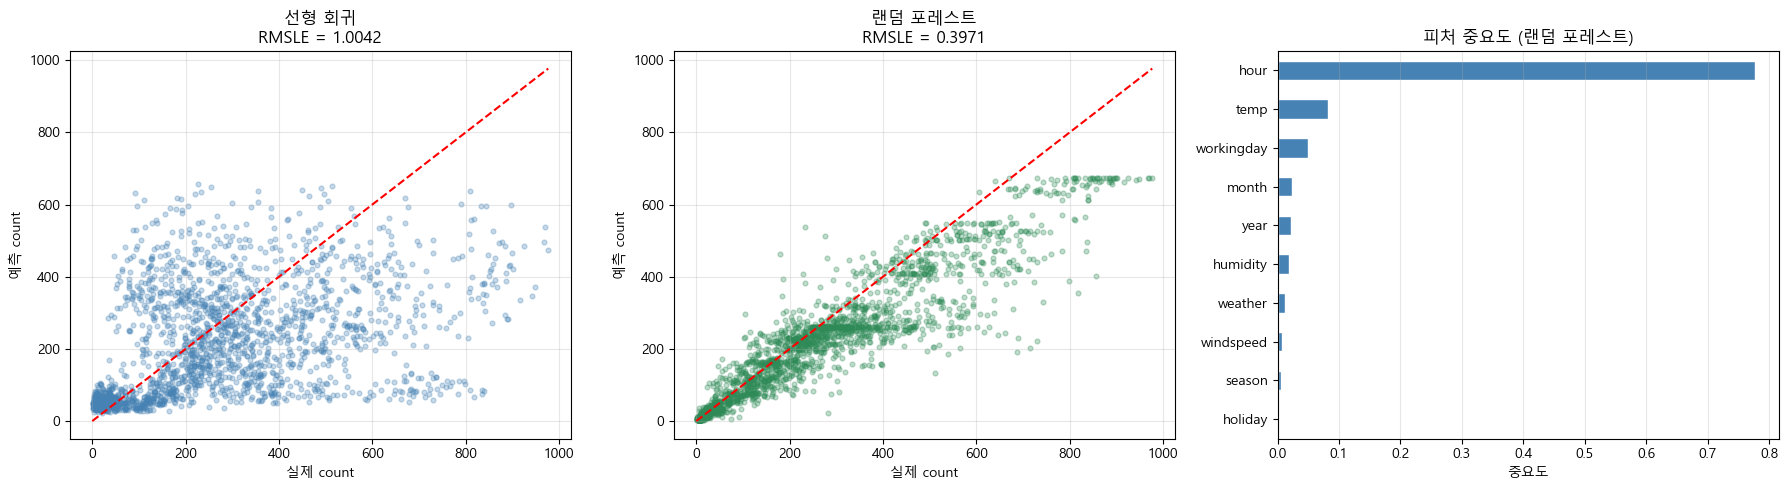

In [47]:
# ── 9. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lim = max(y_test_raw.max(), rf_pred_raw.max())

# (A) LinearRegression 실제 vs 예측
axes[0].scatter(y_test_raw, lr_pred_raw, alpha=0.3, s=12, color='steelblue')
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[0].set_xlabel('실제 count')
axes[0].set_ylabel('예측 count')
axes[0].set_title(f'선형 회귀\nRMSLE = {lr_rmsle:.4f}')
axes[0].grid(alpha=0.3)

# (B) RandomForest 실제 vs 예측
axes[1].scatter(y_test_raw, rf_pred_raw, alpha=0.3, s=12, color='seagreen')
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[1].set_xlabel('실제 count')
axes[1].set_ylabel('예측 count')
axes[1].set_title(f'랜덤 포레스트\nRMSLE = {rf_rmsle:.4f}')
axes[1].grid(alpha=0.3)

# (C) 피처 중요도
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('피처 중요도 (랜덤 포레스트)')
axes[2].set_xlabel('중요도')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

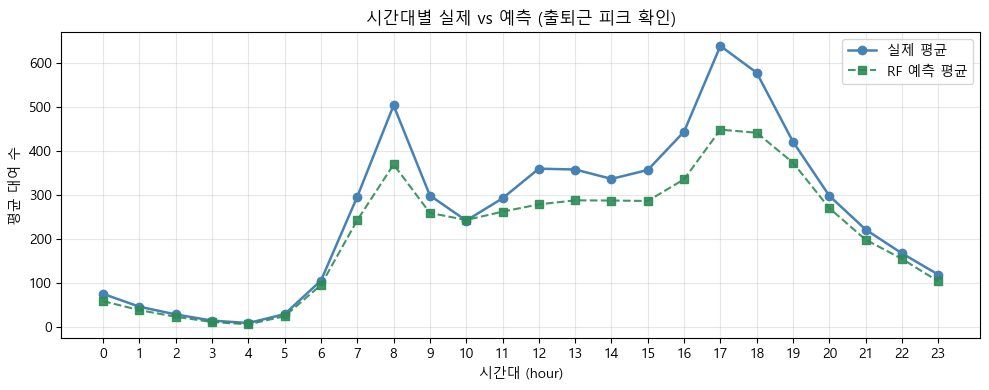

In [48]:
# ── 10. 시간대별 예측 패턴 분석 ──────────────────────────
result_df = X_test2.copy()
result_df['실제값'] = y_test_raw.values
result_df['예측값'] = rf_pred_raw

hourly = result_df.groupby('hour')[['실제값', '예측값']].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly.index, hourly['실제값'], 'o-',  label='실제 평균', color='steelblue', linewidth=1.8)
plt.plot(hourly.index, hourly['예측값'], 's--', label='RF 예측 평균', color='seagreen', alpha=0.9)
plt.xticks(range(0, 24))
plt.xlabel('시간대 (hour)')
plt.ylabel('평균 대여 수')
plt.title('시간대별 실제 vs 예측 (출퇴근 피크 확인)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

>**내용**  
>비선형 모델 도입 : 선형 회귀 한계 극복을 위한 랜덤 포레스트 알고리즘 도입  
>성능 지표 쳬계화 및 비교 : RMSE 와 RMSLE 모델별 성능 정략적 비교, 선형 회귀(원본) / 선형 회귀(개선) / 랜덤 포레스트 3가지 비교표 작성  
>심층 시각화 분석 : 실제값과 예측값의 산점도를 그려 각 모델별 데이터가 얼마나 잘 따라가는지 시각적 대조하였음, 랜덤 포레스트가 학습 과정에서 어떤 변수를 가장 중요하게 판단했는지 그래프로 도출, 시간별 평균 대여 수를 그룹화하여 실제 수요 패턴을 모델이 얼마나 모사하는지 최종 검증

>**결과**  
>성능 검증 : 선형회귀(개선) 모델 대비 랜덤포레스트 모델의 RMSLE 값이 1.0042에서 0.3971로 크게 감소하여 예측 정밀도가 대폭 향상되었음  
>패턴 학습 능력 검증 : 출되근 시간대의 복합적인 수요 급증 패턴을 랜덤 포레스트 모델이 효과적으로 예측하고 있음  
>데이터 해석 : 피처 중요도 분석을 통해 예측값만 내는 것이 아닌 어떤 요소가 자전거 대여에 결정적인지 인사이트 확보  

## 회고

> 아직 개념적인 이해가 부족하나 코딩 작업을 통해 데이터 분석의 과정을 일부분 이해할 수 있었음  
> AI를 통해 학습한 부분 중 RMSLE(log 변환), Randomporest 등 미리 예습할 수 있었음  
> 각 상황에서 적절한 분석기법을 사용할 줄 알아야하기에 다양한 방식으로 접근하고자 시도해보는게 좋을 것 같다  
> 더욱 익숙해진다면 그래프를 보고 무엇이 문제이고 어떻게 조치를 취할지 구분할 수 있도록 노력하겠음...  